# MNIST Handwritten Digit Classifier

A fully connected neural network (MLP) built with PyTorch to classify handwritten digits (0–9).

## Overview

| | |
|---|---|
| **Dataset** | MNIST — 60k train / 10k test, 28×28 grayscale |
| **Model** | MLP: 784 → 128 → 64 → 10, with Dropout(0.3) |
| **Loss** | CrossEntropyLoss |
| **Optimizer** | Adam (lr=0.001) |
| **Framework** | PyTorch |

## How to run
Click **Runtime → Run all** or execute cells one by one. GPU is optional (CPU is fast enough).

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alicelmre2705/deep-learning-projects/blob/main/mnist_digit_classifier.ipynb)

## 1. Setup

In [1]:
# Install dependencies (Colab has most of these, but just in case)
!pip install -q torch torchvision numpy matplotlib scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/deep-learning-results'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Results will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/deep-learning-results


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Data Loading and Exploration

MNIST is automatically downloaded via `torchvision`. Images are normalized to [0, 1] and fed through a `DataLoader` for batched training.

In [3]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 20
NUM_CLASSES = 10

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.49MB/s]

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])


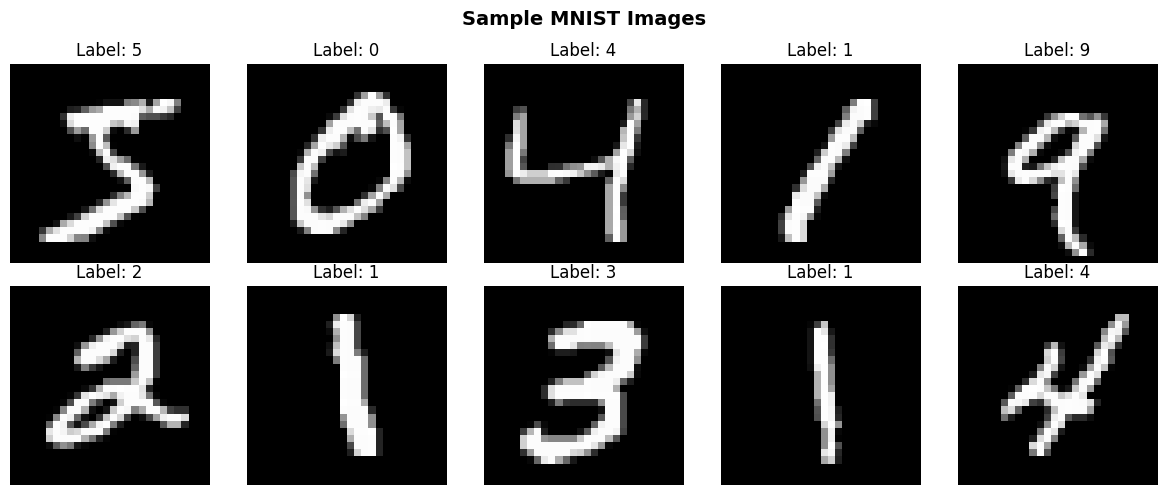

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}", fontsize=12)
    ax.axis("off")
plt.suptitle("Sample MNIST Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Model Definition

A 3-layer MLP. The input (28×28 = 784 pixels) is flattened, then passed through two hidden layers with ReLU activation.

`CrossEntropyLoss` internally applies LogSoftmax, so no activation is needed on the output layer.

In [6]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, NUM_CLASSES),
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Architecture : 784 → Linear(128) → Dropout → Linear(64) → Dropout → Linear(10)")
print(f"Total params : {total_params:,}")
print(f"Device       : {device}")

Architecture : 784 → Linear(128) → Dropout → Linear(64) → Dropout → Linear(10)
Total params : 109,386
Device       : cuda


## 4. Training

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Evaluate on test set
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    test_acc = test_correct / test_total
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  Loss: {epoch_loss:.4f}  |  Train: {epoch_acc:.4f}  |  Test: {test_acc:.4f}")

print(f"\nDone. Final test accuracy: {test_accuracies[-1]:.4f}")

Epoch  1/20  |  Loss: 0.5456  |  Train: 0.8398  |  Test: 0.9397
Epoch  2/20  |  Loss: 0.2490  |  Train: 0.9283  |  Test: 0.9546
Epoch  3/20  |  Loss: 0.1946  |  Train: 0.9429  |  Test: 0.9611
Epoch  4/20  |  Loss: 0.1628  |  Train: 0.9520  |  Test: 0.9675
Epoch  5/20  |  Loss: 0.1429  |  Train: 0.9580  |  Test: 0.9701
Epoch  6/20  |  Loss: 0.1293  |  Train: 0.9627  |  Test: 0.9733
Epoch  7/20  |  Loss: 0.1158  |  Train: 0.9659  |  Test: 0.9730
Epoch  8/20  |  Loss: 0.1080  |  Train: 0.9678  |  Test: 0.9734
Epoch  9/20  |  Loss: 0.1015  |  Train: 0.9690  |  Test: 0.9755
Epoch 10/20  |  Loss: 0.0963  |  Train: 0.9708  |  Test: 0.9757
Epoch 11/20  |  Loss: 0.0907  |  Train: 0.9726  |  Test: 0.9764
Epoch 12/20  |  Loss: 0.0856  |  Train: 0.9739  |  Test: 0.9771
Epoch 13/20  |  Loss: 0.0831  |  Train: 0.9747  |  Test: 0.9773
Epoch 14/20  |  Loss: 0.0771  |  Train: 0.9756  |  Test: 0.9781
Epoch 15/20  |  Loss: 0.0777  |  Train: 0.9754  |  Test: 0.9778
Epoch 16/20  |  Loss: 0.0731  |  Train: 

## 5. Training Curves

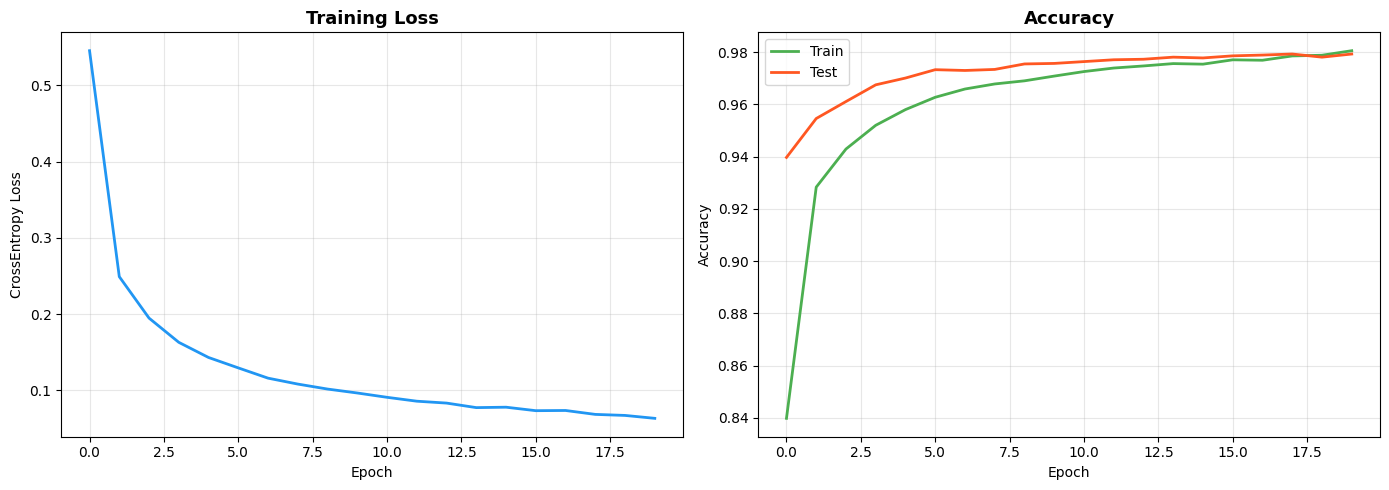

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color="#2196F3", linewidth=2)
ax1.set_title("Training Loss", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies, label="Train", color="#4CAF50", linewidth=2)
ax2.plot(test_accuracies, label="Test", color="#FF5722", linewidth=2)
ax2.set_title("Accuracy", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [9]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



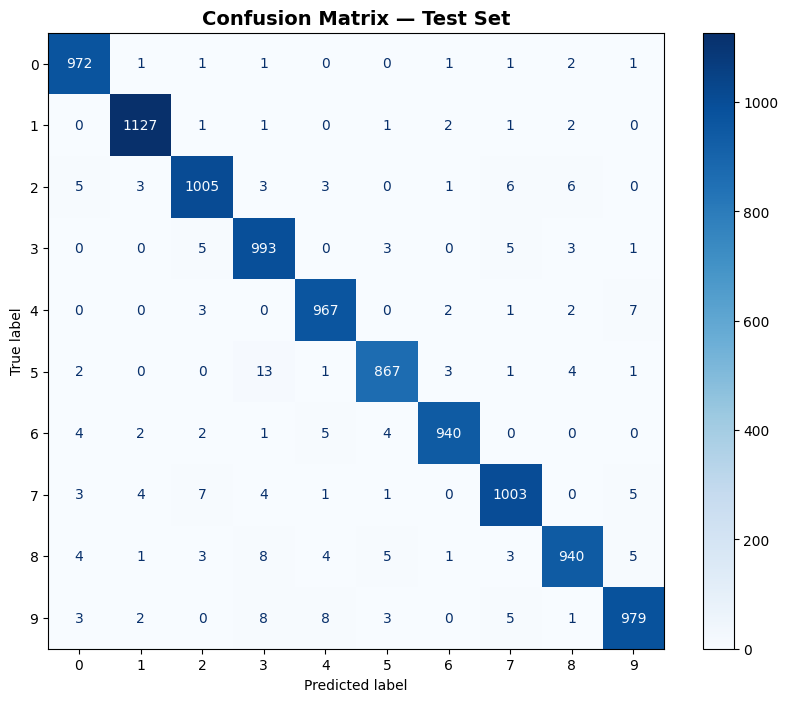

In [10]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.show()

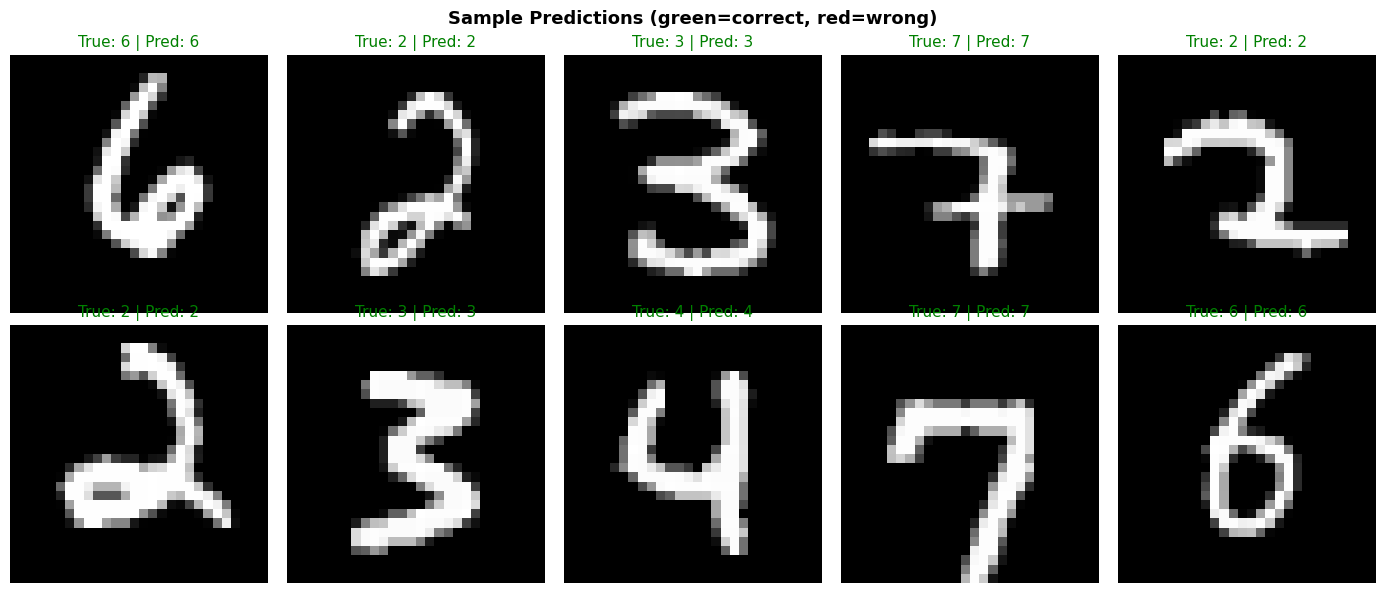

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
indices = np.random.choice(len(test_dataset), 10, replace=False)

for i, ax in enumerate(axes.flat):
    image, true_label = test_dataset[indices[i]]
    pred_label = all_preds[indices[i]]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color=color, fontsize=11)
    ax.axis("off")

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Save Model

In [ ]:
import shutil, os, json, time
from IPython.display import Javascript, display

# Save model weights to Drive
torch.save(model.state_dict(), 'mnist_mlp.pth')
shutil.copy('mnist_mlp.pth', f'{SAVE_DIR}/mnist_mlp.pth')
print(f'Saved  →  {SAVE_DIR}/mnist_mlp.pth')

# Save this notebook (with outputs) to Drive
from google.colab import _message

# Trigger a checkpoint first so all outputs are flushed
display(Javascript('IPython.notebook.save_checkpoint();'))
time.sleep(3)

try:
    nb_data = _message.blocking_request('get_ipynb', request={}, timeout_sec=120)
    dest = '/content/drive/MyDrive/Colab Notebooks/mnist_digit_classifier.ipynb'
    with open(dest, 'w') as f:
        json.dump(nb_data['ipynb'], f, indent=1, ensure_ascii=False)
    size_kb = os.path.getsize(dest) / 1024
    print(f'Notebook saved  →  Colab Notebooks/mnist_digit_classifier.ipynb  ({size_kb:.0f} KB)')
except Exception as e:
    print(f'Auto-save failed: {e}')
    print('→ File → Save a copy in Drive')

Saved  →  /content/drive/MyDrive/deep-learning-results/mnist_mlp.pth
Notebook saved  →  Colab Notebooks/mnist_digit_classifier.ipynb  (142 KB)


## 8. Conclusion

**Results**: A 3-layer MLP with Dropout achieves ~98% test accuracy on MNIST.

**Key takeaways**:
- `CrossEntropyLoss` combines LogSoftmax + NLLLoss — standard for multi-class classification.
- The model converges within ~15 epochs on MNIST.
- Dropout(0.3) reduces overfitting and keeps train/test accuracy close.
- Most errors occur between visually similar digits (3/5, 4/9, 7/9).

**Possible improvements**:
- Use a CNN to capture spatial features (→ 99%+ accuracy)
- Add BatchNorm for faster convergence
- Try data augmentation (rotation, slight shifts)